In [1]:
import warnings
warnings.filterwarnings("ignore")
from test_multicommodity import test_main, create_forcing, plot_result
from mcopt_misc import plot_network, run_mcopt
import sys
sys.path.append('../src/')
import numpy as np
from mcopt import McOpt, paris_topology
from typing import Dict, List, Tuple
import networkx as nx
import matplotlib.pyplot as plt

#### Compare With McOpt

In [2]:
def constrcut_mcopt(beta: float=1.0, method="paris"):
    method, coupling, museed, pflux, rho = method, "l1", 0, beta, 0.0   
    time_step, tot_time, relax_linsys, tau_cond_dyn, tau_cost_dyn = 0.5, 10000, 1.0e-5, 1.0e-1, 1.0e-1
    tau_cond_opt, tau_cost_opt = 1.0e-1, 1.0e-1
    VERBOSE = False
    mcopt = McOpt(method, coupling, museed, pflux, VERBOSE, rho, relax_linsys, tau_cond_dyn, tau_cost_dyn, time_step, tot_time, tau_cond_opt, tau_cost_opt)
    mcopt.ot_setup()
    return mcopt

In [3]:
def compare_mcopt_admk(beta: float=1.0, method="paris"):
    mcopt = constrcut_mcopt(beta=beta, method=method)
    forcing, conductivity_mcopt = run_mcopt(mcopt)
    topo, weights, forcing_ = mcopt.export_setup()
    potentials, conductivity_admk = test_main(topo.copy(), weights, len(forcing_), forcing_, beta=beta, max_iter=25)
    plot_network(mcopt.g, forcing, conductivity_mcopt, conductivity_admk)
    return mcopt.g, forcing_

* graph topology construction
* running [dynamics]
	convergence achieved [dynamics]
* export fluxes
* export cost
init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0010 max(res)=7.4e-09 max(pres)=6.4e-12
   -2.00e+00<=UPDATE<=-2.00e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=1 var=1.11e+00
   -1.80e+00<=UPDATE<=-1.80e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=2 var=1.11e+00
   -1.62e+00<=UPDATE<=-1.62e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=3 var=1.11e+00
   -1.46e+00<=UPDATE<=-1.46e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=4 var=1.11e+00
   -1.31e+00<=UPDATE<=-1.31e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=5 var=1.11e+00
   -1.18e+00<=U

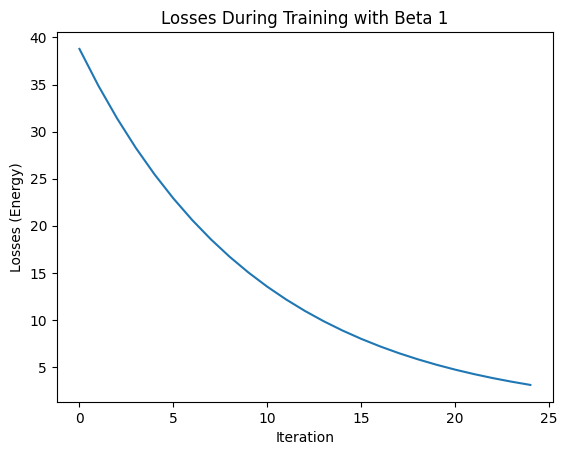

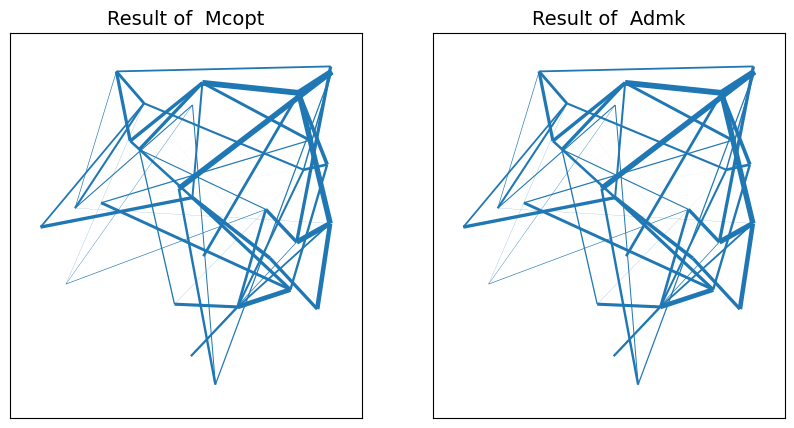

In [4]:
graph, forcing = compare_mcopt_admk(1, "synth")

###### Apply Fine-Grain Method On Waxman Graph

In [5]:
def discretize(graph: nx.Graph, forcing: List[np.ndarray], mesh_size=30, beta=1, max_iter=20):
    num_commodity = len(graph.nodes)
    def grid_coord_idx(coord: Tuple[int, int]): 
        return coord[0] * mesh_size + coord[1]
    
    mesh = nx.grid_2d_graph(mesh_size, mesh_size)
    forcing_grid = [np.zeros(num_commodity) for _ in range(mesh_size * mesh_size)]
    for node in graph.nodes:
        cur_pos_on_grid: Tuple[int, int] = (round(graph.nodes[node]["pos"][0] * mesh_size), round(graph.nodes[node]["pos"][1] * mesh_size))
        print(f"Original pos: {graph.nodes[node]['pos']} | Pos on grid: {cur_pos_on_grid}")
        cur_pos_idx = grid_coord_idx(cur_pos_on_grid)
        for comm in range(num_commodity):
            forcing_grid[cur_pos_idx][comm] += forcing[node][comm] * 1e5
    for node in mesh.nodes():
        mesh.nodes[node]["amplitude"] = np.linalg.norm(forcing_grid[grid_coord_idx(node)])
    edge_lists = np.array([list((grid_coord_idx(e[0]), grid_coord_idx(e[1]))) for e in mesh.edges()])
    weights = np.ones_like(edge_lists[:,0])
    potentials, conductivity_admk = test_main(edge_lists, weights, len(forcing_grid), forcing_grid, beta=beta, max_iter=max_iter)
    return mesh, conductivity_admk    

The scale of the `forcing` needs to be altered for different methods and topology, here we set it to `1e5`, which <ins>might not work</ins> for alternative problems (optimization might not run properly).

Original pos: (0.8444218515250481, 0.7579544029403025) | Pos on grid: (25, 23)
Original pos: (0.420571580830845, 0.25891675029296335) | Pos on grid: (13, 8)
Original pos: (0.5112747213686085, 0.4049341374504143) | Pos on grid: (15, 12)
Original pos: (0.7837985890347726, 0.30331272607892745) | Pos on grid: (24, 9)
Original pos: (0.4765969541523558, 0.5833820394550312) | Pos on grid: (14, 18)
Original pos: (0.9081128851953352, 0.5046868558173903) | Pos on grid: (27, 15)
Original pos: (0.28183784439970383, 0.7558042041572239) | Pos on grid: (8, 23)
Original pos: (0.6183689966753316, 0.25050634136244054) | Pos on grid: (19, 8)
Original pos: (0.9097462559682401, 0.9827854760376531) | Pos on grid: (27, 29)
Original pos: (0.8102172359965896, 0.9021659504395827) | Pos on grid: (24, 27)
Original pos: (0.3101475693193326, 0.7298317482601286) | Pos on grid: (9, 22)
Original pos: (0.8988382879679935, 0.6839839319154413) | Pos on grid: (27, 21)
Original pos: (0.47214271545271336, 0.1007012080683658

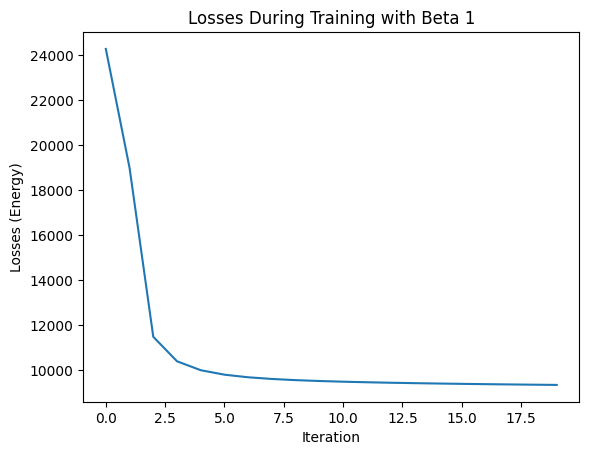

In [6]:
mesh, conductivity_admk = discretize(graph, forcing)

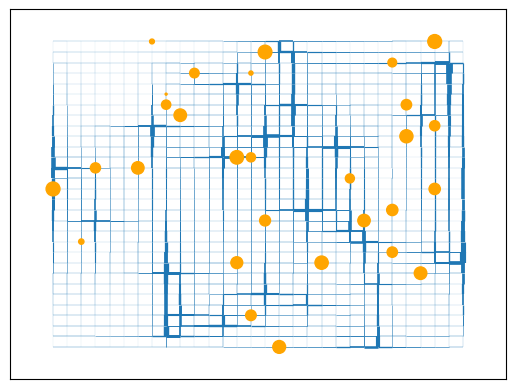

In [7]:
plt.show()
pos = {n: (n[0], n[1]) for n in mesh.nodes()}
nx.draw_networkx_edges(mesh, pos=pos, width=np.array(conductivity_admk) * 0.1,  edge_color='C0', style='solid')
amps = [mesh.nodes[n]['amplitude']  for n in mesh.nodes()]
nx.draw_networkx_nodes(mesh, pos=pos, node_size=amps, node_color='orange')
plt.show()

We set beta to a different value to observe if the generated result has a different pattern.

Original pos: (0.8444218515250481, 0.7579544029403025) | Pos on grid: (25, 23)
Original pos: (0.420571580830845, 0.25891675029296335) | Pos on grid: (13, 8)
Original pos: (0.5112747213686085, 0.4049341374504143) | Pos on grid: (15, 12)
Original pos: (0.7837985890347726, 0.30331272607892745) | Pos on grid: (24, 9)
Original pos: (0.4765969541523558, 0.5833820394550312) | Pos on grid: (14, 18)
Original pos: (0.9081128851953352, 0.5046868558173903) | Pos on grid: (27, 15)
Original pos: (0.28183784439970383, 0.7558042041572239) | Pos on grid: (8, 23)
Original pos: (0.6183689966753316, 0.25050634136244054) | Pos on grid: (19, 8)
Original pos: (0.9097462559682401, 0.9827854760376531) | Pos on grid: (27, 29)
Original pos: (0.8102172359965896, 0.9021659504395827) | Pos on grid: (24, 27)
Original pos: (0.3101475693193326, 0.7298317482601286) | Pos on grid: (9, 22)
Original pos: (0.8988382879679935, 0.6839839319154413) | Pos on grid: (27, 21)
Original pos: (0.47214271545271336, 0.1007012080683658

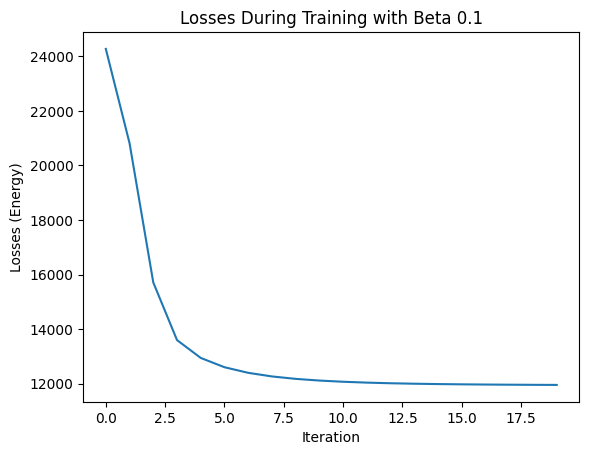

In [8]:
mesh, conductivity_admk = discretize(graph, forcing, beta=0.1)

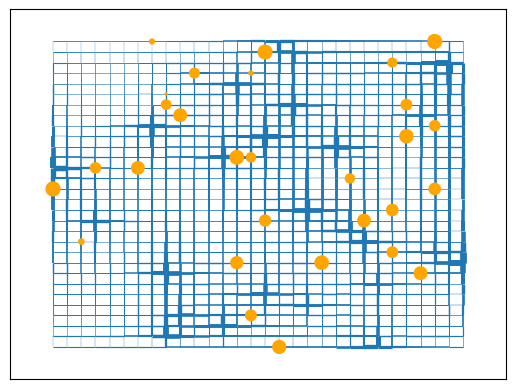

In [12]:
plt.show()
pos = {n: (n[0], n[1]) for n in mesh.nodes()}
nx.draw_networkx_edges(mesh, pos=pos, width=np.array(conductivity_admk) * 0.4,  edge_color='C0', style='solid')
amps = [mesh.nodes[n]['amplitude']  for n in mesh.nodes()]
nx.draw_networkx_nodes(mesh, pos=pos, node_size=amps, node_color='orange')
plt.show()

**Conclusions**: 
1. It seems that we need to postprocess the result generating from the mesh. For instance, we need run some <inv>pruning algorithm</inv> to remove unnecessary edges (whose conductivity is so small), while maintaining the connectivity of the graph.
2. Though we are not allowed to provide the edge information, but if certain amount of mass is transferred from vertex $u$ to $v$, shaall we add weights of the edge that connect the paths between $u$ and $v$. 